# Stroke Prediction Project
---
## Table of Contents

- [1. Introduction](#1-introduction)
- [2. Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)
- [3. Statistical Inference](#3-statistical-inference)
- [4. Machine Learning Models](#4-machine-learning-models)
- [5. Hyperparameter Tuning](#5-hyperparameter-tuning)
- [6. Ensemble Model](#6-ensemble-model)
- [7. Conclusions](#7-conclusions)

## 1. Introduction

This notebook explores a clinical-style dataset on stroke. Our goal is twofold:

- Understand the data—its distributions, missingness, and key statistical summaries;

- Build a predictive model that flags high-risk cases using modern ML practices.

What we do:

- Exploratory analysis (EDA): inspect target prevalence, feature distributions (e.g., age, BMI, glucose), correlations, and missing values; document initial hypotheses about risk factors.

- Preprocessing: impute missing values (median/mode), standardize numeric features, and one-hot encode categoricals inside a scikit-learn Pipeline to avoid data leakage.

- Modeling: train several baselines and a Gradient Boosting classifier; optionally compare LightGBM/XGBoost; combine models with a soft-voting ensemble.

- Imbalance handling: use class/sample weights (and optional resampling) to better capture the minority class (stroke=1).

- Evaluation: report ROC AUC and PR AUC, visualize ROC/PR curves, and select an operating threshold (e.g., max F1 or target recall) aligned with the screening objective.

The result is a concise, reproducible workflow that moves from data understanding to a calibrated, thresholded predictor suitable for decision support.
.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    f1_score,
)
from lightgbm import LGBMClassifier

In [146]:
# Load dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 1. Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

Statistical Summary:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000



Missing and duplicates values per column:


,missing
bmi,201
id,0
age,0
gender,0
hypertension,0
heart_disease,0
work_type,0
ever_married,0
Residence_type,0
avg_glucose_level,0



Total duplicates: 0
Dataframe size after dropping NaNs: (5110, 12)


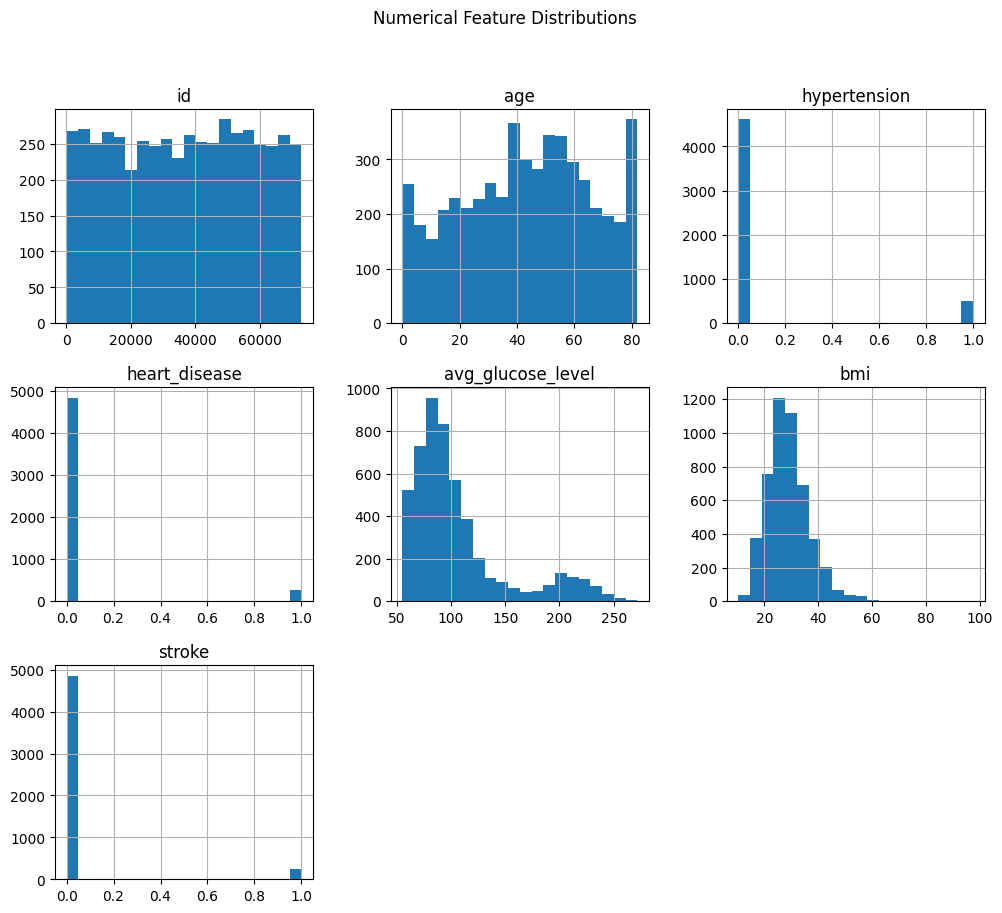

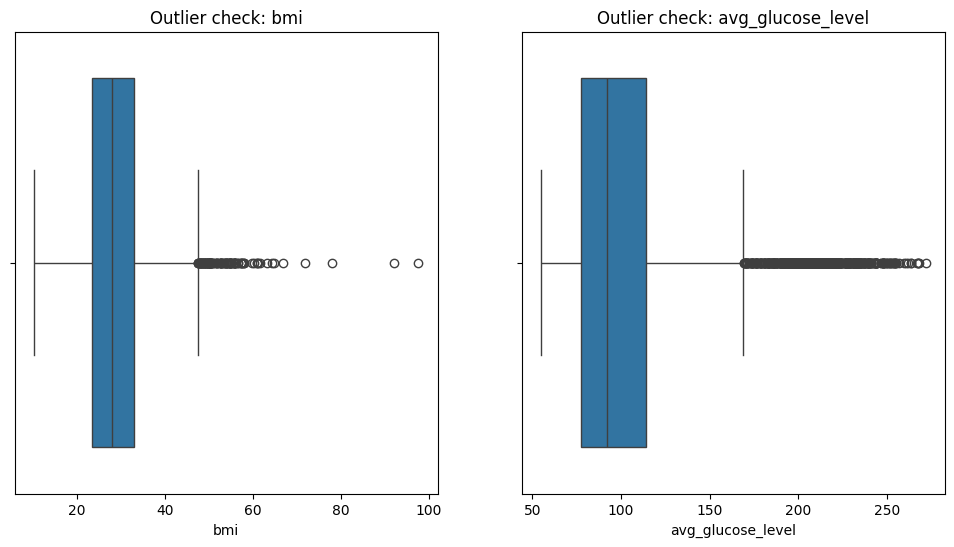

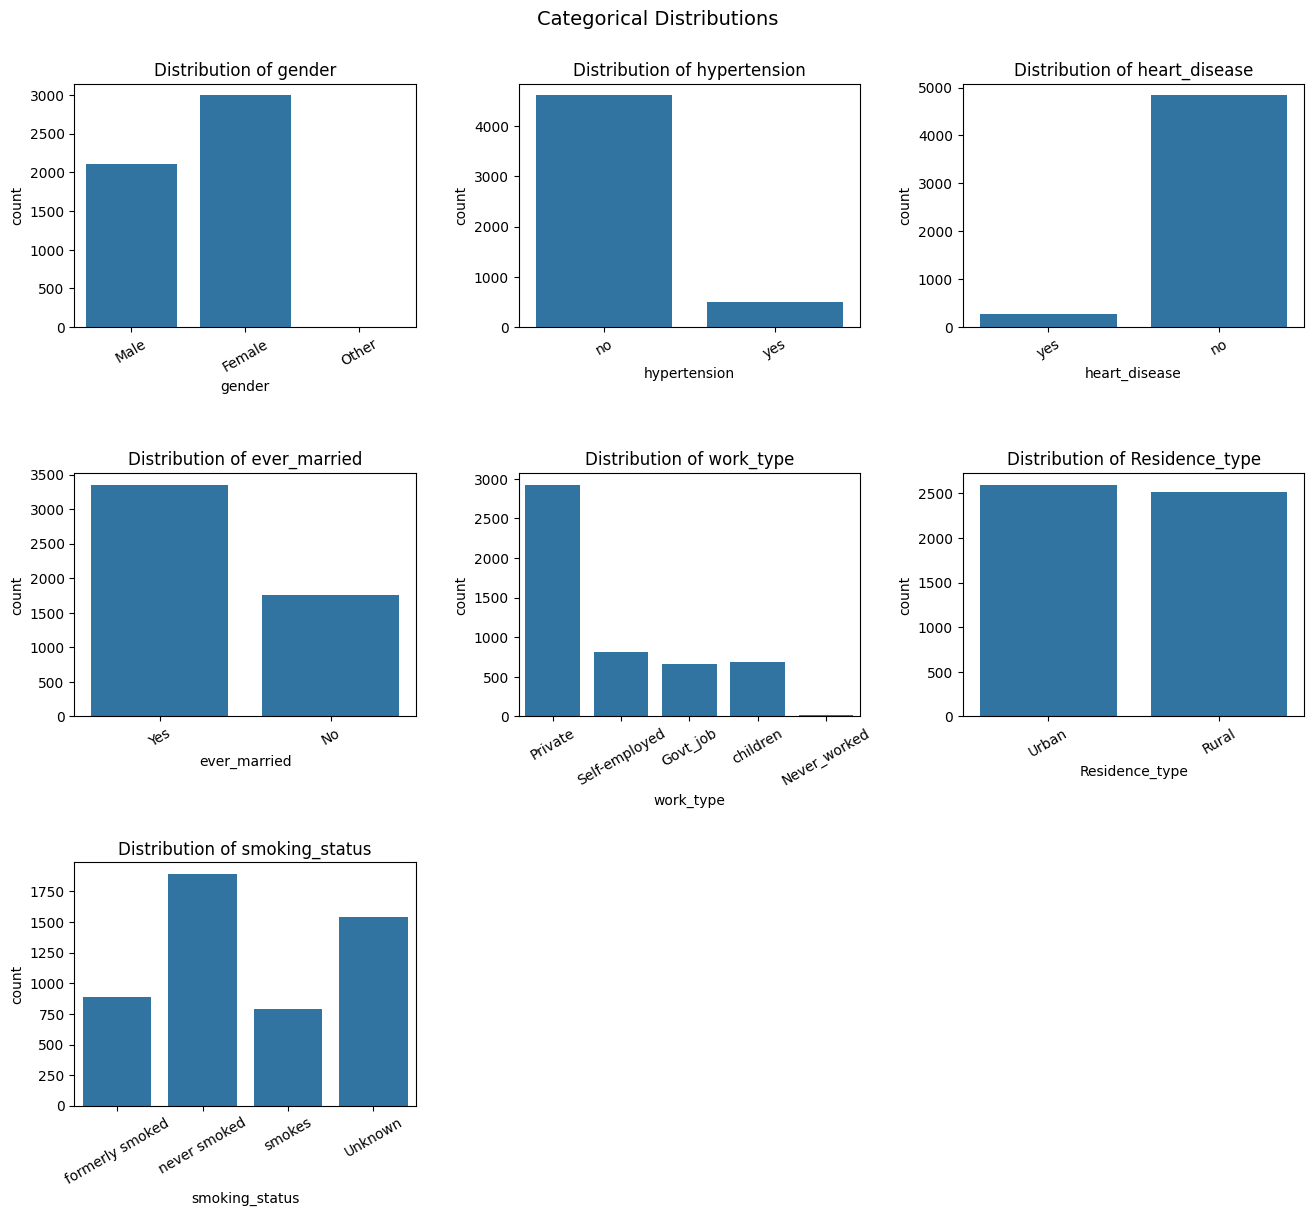

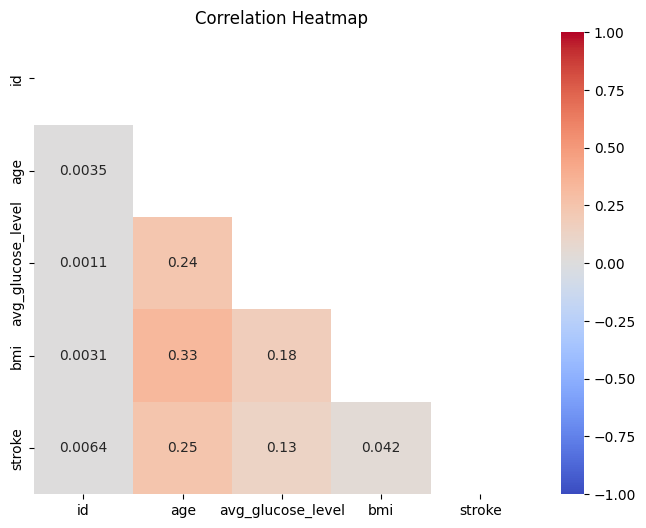

Cramer's V between stroke and gender: 0.0096
Cramer's V between stroke and hypertension: 0.1264
Cramer's V between stroke and heart_disease: 0.1329
Cramer's V between stroke and ever_married: 0.1074
Cramer's V between stroke and work_type: 0.0981
Cramer's V between stroke and Residence_type: 0.0145
Cramer's V between stroke and smoking_status: 0.0755


In [ ]:
# Basic info and stats
print(df.info())
print("\nStatistical Summary:")
display(df.describe(include="all"))
na_counts = df.isna().sum().sort_values(ascending=False)
print("\nMissing and duplicates values per column:")
df_na = na_counts.to_frame("missing")
display(df_na)
print(f"\nTotal duplicates: {df.duplicated().sum()}")
df.dropna()
print("Dataframe size after dropping NaNs:", df.shape)

# Histograms
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

# Outlier check
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="bmi", ax=plt.subplot(1, 2, 1))
plt.title(f"Outlier check: bmi")
sns.boxplot(data=df, x="avg_glucose_level", ax=plt.subplot(1, 2, 2))
plt.title(f"Outlier check: avg_glucose_level")
plt.show()

# turn hypertention and heart_disease into categorical
df["hypertension"] = df["hypertension"].astype("object")
df["hypertension"] = df["hypertension"].replace({0: "no", 1: "yes"})
df["heart_disease"] = df["heart_disease"].astype("object")
df["heart_disease"] = df["heart_disease"].replace({0: "no", 1: "yes"})


# Categorical balance
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
nplots = len(categorical_cols)

# choose up to 3 columns
ncols = min(3, nplots) if nplots > 0 else 1
# compute rows without math.ceil
nrows = (nplots + ncols - 1) // ncols  # ceiling division trick

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.0 * nrows))
axes = np.atleast_1d(axes).ravel()  # flatten whether 1 or many axes

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis="x", rotation=30)

# hide any unused axes (in case grid > nplots)
for j in range(nplots, len(axes)):
    axes[j].set_visible(False)

# spacing so titles/labels don't overlap
fig.tight_layout(pad=2.0)
plt.subplots_adjust(hspace=0.6, wspace=0.3)
fig.suptitle("Categorical Distributions", y=1.02, fontsize=14)

plt.show()

# Correlations
plt.figure(figsize=(8, 6))
# Compute the correlation matrix
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    df.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    annot=True,
    cmap="coolwarm",
    center=0,
    mask=mask,
)
plt.title("Correlation Heatmap")
plt.show()


# Categorical correlation with Cramer's V
def Cramer(column1, column2):
    confusion_matrix = pd.crosstab(column1, column2)
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))
    print(f"Cramer's V between {column1.name} and {column2.name}: {cramers_v:.4f}")


# Calculate Cramer's V for categorical features
for col in categorical_cols:
    Cramer(df["stroke"], df[col])

## 2. Statistical Inference

In [ ]:
# Use the Chi square to test stroke vs heart_disease and stroke vs hypertension

chi2, p, dof, expected = stats.chi2_contingency(
    pd.crosstab(df["stroke"], df["heart_disease"])
)
print("Chisquare between stroke and heart_disease:", chi2, "p-value:", p)

# Confidence interval calculation

chi2, p, dof, expected = stats.chi2_contingency(
    pd.crosstab(df["stroke"], df["hypertension"])
)
print("Chisquare between stroke and hypertension:", chi2, "p-value:", p)

# Use Welch's t-test to compare stroke vs age and stroke vs avg_glucose_level
t_stats, p_value = stats.ttest_ind(
    df[df["stroke"] == 1]["age"], df[df["stroke"] == 0]["age"], equal_var=False
)
print("T-test between stroke and age: t-statistic =", t_stats, "p-value =", p_value)

t_stats, p_value = stats.ttest_ind(
    df[df["stroke"] == 1]["avg_glucose_level"],
    df[df["stroke"] == 0]["avg_glucose_level"],
    equal_var=False,
)
print(
    "T-test between stroke and avg_glucose_level: t-statistic =",
    t_stats,
    "p-value =",
    p_value,
)

# Confidence Intervals (95%)
stroke_group = df[df["stroke"] == 1]["avg_glucose_level"]

conf_interval = stats.norm.interval(
    0.95, loc=np.mean(stroke_group), scale=stats.sem(stroke_group)
)
print("95% CI (Stroke group mean glucose):", conf_interval)

stroke_group = df[df["stroke"] == 1]["age"]

conf_interval = stats.norm.interval(
    0.95, loc=np.mean(stroke_group), scale=stats.sem(stroke_group)
)
print("95% CI (Agw group mean glucose):", conf_interval)

Chisquare between stroke and heart_disease: 90.25956125843324 p-value: 2.0887845685229236e-21
Chisquare between stroke and hypertension: 81.6053682482931 p-value: 1.661621901511823e-19
T-test between stroke and age: t-statistic = 29.68626563006023 p-value = 2.115684848347272e-95
T-test between stroke and avg_glucose_level: t-statistic = 6.982411744792963 p-value = 2.4014366563697676e-11
95% CI (Stroke group mean glucose): (np.float64(124.85366887388554), np.float64(140.23580903776102))
95% CI (Agw group mean glucose): (np.float64(66.14734965810584), np.float64(69.30903588406284))


## 3. Machine Learning Models

In [ ]:
# ---------- Split ----------
X = df.drop(columns=["stroke", "id"])
y = df["stroke"]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------- Preprocess ----------
num = ["age", "avg_glucose_level", "bmi"]
cat = [c for c in X.columns if c not in num]

num_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),  # use sparse=False if sklearn < 1.2
    ]
)

prep = ColumnTransformer(
    [
        ("num", num_pipe, num),
        ("cat", cat_pipe, cat),
    ]
)

# ---------- Baseline (dummy) ----------
baseline = Pipeline(
    [("prep", prep), ("clf", DummyClassifier(strategy="most_frequent"))]
)
baseline.fit(X_tr, y_tr)
print(
    "Baseline ROC AUC (test):", roc_auc_score(y_te, baseline.predict_proba(X_te)[:, 1])
)

# ---------- Models ----------

# compute class ratio on TRAIN
pos = int((y_tr == 1).sum())
neg = int((y_tr == 0).sum())
spw = neg / max(pos, 1)  # scale_pos_weight

models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RF": RandomForestClassifier(class_weight="balanced_subsample", random_state=42),
    "GBDT": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=11, weights="distance"),
    "LightGBM": LGBMClassifier(random_state=42, scale_pos_weight=spw),
}


def make_pipe(est):
    return Pipeline([("prep", prep), ("clf", est)])


# ---------- CV compare (train only) ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {}
for name, est in models.items():
    pipe = make_pipe(est)
    scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_scores[name] = scores.mean()
    print(f"{name}: ROC AUC {scores.mean():.3f} ± {scores.std():.3f}")

# pick best by CV, fit on full train, evaluate on test
best_name = max(cv_scores, key=cv_scores.get)
best_pipe = make_pipe(models[best_name]).fit(X_tr, y_tr)

y_prob = best_pipe.predict_proba(X_te)[:, 1]
print(f"\nBest model: {best_name}")
print("Test ROC AUC:", roc_auc_score(y_te, y_prob))
print("Test PR  AUC:", average_precision_score(y_te, y_prob))

Baseline ROC AUC (test): 0.5
LogReg: ROC AUC 0.839 ± 0.011
RF: ROC AUC 0.803 ± 0.021
GBDT: ROC AUC 0.843 ± 0.015
KNN: ROC AUC 0.682 ± 0.047
LightGBM: ROC AUC 0.823 ± 0.024

Best model: GBDT
Test ROC AUC: 0.8343312757201645
Test PR  AUC: 0.21103039672982088


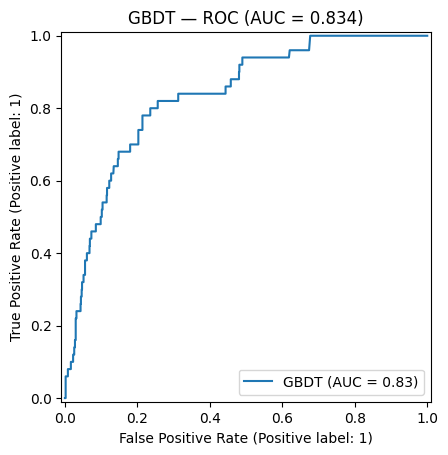

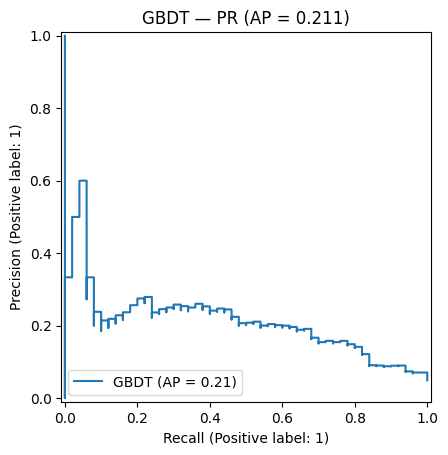

Chosen threshold (max F1): 0.14 | F1=0.314
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       972
           1       0.24      0.44      0.31        50

    accuracy                           0.91      1022
   macro avg       0.61      0.69      0.63      1022
weighted avg       0.93      0.91      0.92      1022



In [ ]:
# 1) Plots
RocCurveDisplay.from_predictions(y_te, y_prob, name=best_name)
plt.title(f"{best_name} — ROC (AUC = {roc_auc_score(y_te, y_prob):.3f})")
plt.show()

PrecisionRecallDisplay.from_predictions(y_te, y_prob, name=best_name)
plt.title(f"{best_name} — PR (AP = {average_precision_score(y_te, y_prob):.3f})")
plt.show()

# 2) Pick a readable threshold (maximize F1 over a simple grid)
cands = np.linspace(0.00, 1.00, 101)  # 0.00, 0.01, ..., 1.00
f1s = [f1_score(y_te, (y_prob >= t).astype(int), zero_division=0) for t in cands]
best_thr = float(cands[int(np.argmax(f1s))])

# 3) Final report at that threshold
y_pred = (y_prob >= best_thr).astype(int)
print(f"Chosen threshold (max F1): {best_thr:.2f} | F1={max(f1s):.3f}")
print(classification_report(y_te, y_pred))

ROC (AUC ≈ 0.84)

Good ranking: the model scores a random positive higher than a random negative ~84% of the time.

Note: ROC is insensitive to class imbalance; it can look strong even when few positives are predicted.

Precision–Recall (AP ≈ 0.23)

Baseline (prevalence) ≈ 50/1022 ≈ 0.05 → AP 0.23 is ~4–5× better than random.

Still many false positives at useful recall: precision drops as recall increases.


Baseline AP is the prevalence (≈ 50/1022 ≈ 0.05 in your test), so 0.23 is ~4–5× better than random—but still low in absolute precision.

The curve shows a familiar trade-off:

At very low recall, precision can be higher (a few highly confident cases).

As you push recall up (catch more strokes), precision falls quickly (more false alarms).

## 4. Hyperparameter Tuning

In [ ]:
pipe_gbdt = Pipeline(
    [("preprocessor", prep), ("model", GradientBoostingClassifier(random_state=42))]
)

param_grid_gbdt = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],  # integers only (no None)
    "model__subsample": [1.0, 0.8],  # try stochastic GB
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipe_gbdt, param_grid_gbdt, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True
)
grid.fit(X_tr, y_tr)

print("Best Params:", grid.best_params_)
print("Best CV ROC AUC:", grid.best_score_)

best_pipe = grid.best_estimator_
y_prob = best_pipe.predict_proba(X_te)[:, 1]

prec, rec, thr = precision_recall_curve(y_te, y_prob)  # len(thr) = len(prec)-1

# F1 per threshold (safe divide)
den = prec[:-1] + rec[:-1]
f1 = np.divide(2 * prec[:-1] * rec[:-1], den, out=np.zeros_like(den), where=den > 0)

ix = int(np.argmax(f1))
best_thr = float(thr[ix])
print(
    f"Best F1 threshold = {best_thr:.3f} | F1={f1[ix]:.3f} | P={prec[ix]:.3f} | R={rec[ix]:.3f}"
)

y_pred = (y_prob >= best_thr).astype(int)
print(classification_report(y_te, y_pred))

Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV ROC AUC: 0.8494541235704475
Best F1 threshold = 0.130 | F1=0.351 | P=0.248 | R=0.600
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       972
           1       0.25      0.60      0.35        50

    accuracy                           0.89      1022
   macro avg       0.61      0.75      0.65      1022
weighted avg       0.94      0.89      0.91      1022



In [152]:
# Example: set threshold = 0.2 instead of 0.5
threshold = best_thr
y_pred = (y_prob >= threshold).astype(int)

print("Test ROC AUC:", roc_auc_score(y_te, y_prob))
print("Test PR  AUC:", average_precision_score(y_te, y_prob))  # useful for imbalance
print(classification_report(y_te, y_pred))
print(confusion_matrix(y_te, y_pred))

Test ROC AUC: 0.8430864197530865
Test PR  AUC: 0.23183412103891263
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       972
           1       0.25      0.60      0.35        50

    accuracy                           0.89      1022
   macro avg       0.61      0.75      0.65      1022
weighted avg       0.94      0.89      0.91      1022

[[881  91]
 [ 20  30]]


## 5. Ensemble Model

In [ ]:
# base models (add class_weight where supported)
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced_subsample", random_state=42
)
gb = GradientBoostingClassifier(random_state=42)

ensemble = VotingClassifier(
    estimators=[("lr", log_reg), ("rf", rf), ("gb", gb)], voting="soft", n_jobs=-1
)

pipe_ensemble = Pipeline(
    [
        ("preprocessor", preprocessor),  # or "prep" if that's your variable
        ("model", ensemble),
    ]
)

# class-balanced sample weights (used for models incl. GBDT)
pos = int((y_tr == 1).sum())
neg = int((y_tr == 0).sum())
w_pos = 0.5 / pos
w_neg = 0.5 / neg
sample_w = np.where(y_tr.values == 1, w_pos, w_neg)

# fit with sample weights (note the param name through the pipeline)
pipe_ensemble.fit(X_tr, y_tr, model__sample_weight=sample_w)

# probs -> choose a threshold (here default 0.5; replace with your F1-optimal)
y_prob = pipe_ensemble.predict_proba(X_te)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_te, y_pred))
print("ROC AUC:", roc_auc_score(y_te, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.79      0.88       972
           1       0.15      0.74      0.25        50

    accuracy                           0.79      1022
   macro avg       0.57      0.76      0.56      1022
weighted avg       0.94      0.79      0.85      1022

ROC AUC: 0.8182716049382717


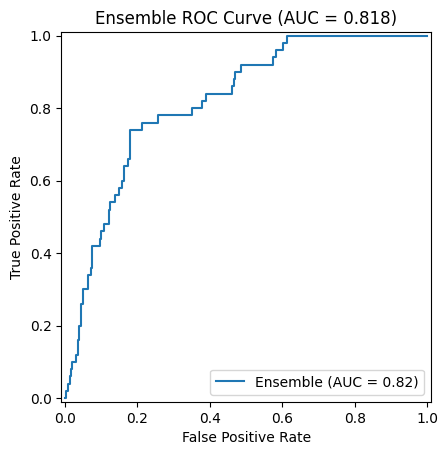

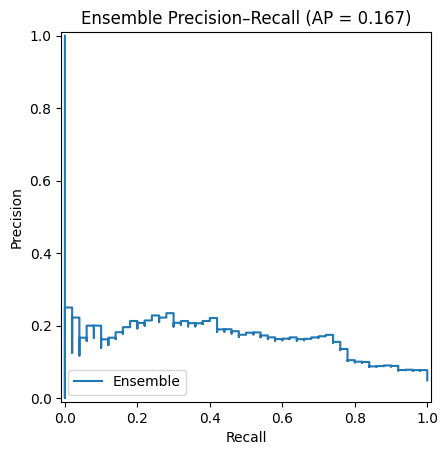

In [154]:
# ROC
roc_auc = roc_auc_score(y_te, y_prob)
fpr, tpr, _ = roc_curve(y_te, y_prob)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="Ensemble").plot()
plt.title(f"Ensemble ROC Curve (AUC = {roc_auc:.3f})")
plt.show()

# Precision–Recall
prec, rec, _ = precision_recall_curve(y_te, y_prob)
ap = average_precision_score(y_te, y_prob)
PrecisionRecallDisplay(precision=prec, recall=rec, estimator_name="Ensemble").plot()
plt.title(f"Ensemble Precision–Recall (AP = {ap:.3f})")
plt.show()

Ensemble summary:

ROC AUC ≈ 0.82 → moderate ranking power, and below the tuned GBDT (~0.84).

PR AP ≈ 0.17 (vs prevalence ≈ 0.05) → ~3× better than random, but precision drops fast as recall increases ⇒ many false positives at useful recall.

Takeaway: this soft-voting ensemble underperforms the best single model. Prefer the tuned GBDT/LightGBM, or tune the ensemble (weights, calibration, class/sample weights) and choose a threshold via PR/Fβ or a top-k policy.